# **Data Anlysis - Blinkit Analysis**

## Objective

The objective of this project is to analyze Blinkit's sales data to identify the factors affecting product sales and provide business recommendations for improving revenue, inventory management, and customer satisfaction.

**Import Libraries**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Import Raw Data**

In [5]:
df = pd.read_csv('blinkit_data.csv')

In [6]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


**Initial audit** — shape, types, duplicates, missing values

In [7]:
df.shape

(8523, 12)

In [8]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='str')

In [9]:
df.dtypes

Item Fat Content                 str
Item Identifier                  str
Item Type                        str
Outlet Establishment Year      int64
Outlet Identifier                str
Outlet Location Type             str
Outlet Size                      str
Outlet Type                      str
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8518    False
8519    False
8520    False
8521    False
8522    False
Length: 8523, dtype: bool

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   str    
 1   Item Identifier            8523 non-null   str    
 2   Item Type                  8523 non-null   str    
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   str    
 5   Outlet Location Type       8523 non-null   str    
 6   Outlet Size                8523 non-null   str    
 7   Outlet Type                8523 non-null   str    
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [12]:
df.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2010.831867,0.066132,12.857645,140.992782,3.965857
std,8.371760,0.051598,4.643456,62.275067,0.605651
min,1998.000000,0.000000,4.555000,31.290000,1.000000
25%,2000.000000,0.026989,8.773750,93.826500,4.000000
50%,2012.000000,0.053931,12.600000,143.012800,4.000000
75%,2017.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


In [13]:
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [14]:
df['Item Weight'] = df['Item Weight'].fillna(df['Item Weight'].median())

Missing values in Item Weight were replaced with the median because the data contains outliers, and the median is less affected by extreme values.

In [15]:
df["Sales Category"] = pd.qcut(
    df["Sales"],
    q=3,
    labels=["Low Sales", "Medium Sales", "High Sales"]
)

df["Sales Category"].value_counts()

Sales Category
Low Sales       2842
High Sales      2841
Medium Sales    2840
Name: count, dtype: int64

In [16]:
df["Outlet Age"] = 2026 - df["Outlet Establishment Year"]

df[["Outlet Establishment Year", "Outlet Age"]].head()

,Outlet Establishment Year,Outlet Age
0,2012,14
1,2022,4
2,2010,16
3,2000,26
4,2015,11


In [17]:
df["Rating Category"] = pd.cut(
    df["Rating"],
    bins=[0, 2.5, 4, 5],
    labels=["Poor", "Average", "Excellent"],
    include_lowest=True
)

df["Rating Category"].value_counts()

Rating Category
Average      5035
Excellent    3172
Poor          316
Name: count, dtype: int64

In [18]:
outlet_sales = df.groupby("Outlet Identifier")["Sales"].transform("mean")
df["Outlet Performance"] = pd.qcut(outlet_sales,q=3,labels=["Low Performing", "Average Performing", "High Performing"])
df["Outlet Performance"].value_counts()

Outlet Performance
Low Performing        3319
High Performing       2788
Average Performing    2416
Name: count, dtype: int64

In [19]:
df["Top Rated"] = df["Rating"].apply(lambda x: "Yes" if x >= 4 else "No")
df["Top Rated"].value_counts()

Top Rated
Yes    6511
No     2012
Name: count, dtype: int64

In [20]:
df["Visibility Category"] = pd.qcut(df["Item Visibility"],q=3,labels=["Low Visibility", "Medium Visibility", "High Visibility"])
df["Visibility Category"].value_counts()

Visibility Category
Low Visibility       2841
Medium Visibility    2841
High Visibility      2841
Name: count, dtype: int64

# Charts

**Which fat content contributes the highest revenue?**


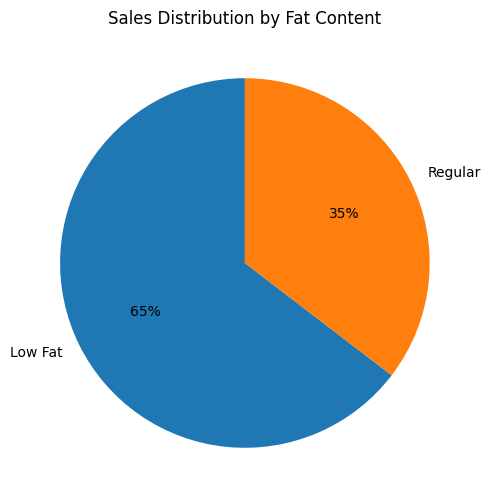

In [21]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(6,6))
plt.pie(sales_by_fat, labels=sales_by_fat.index, autopct="%.0f%%", startangle=90)
plt.title("Sales Distribution by Fat Content")
plt.show()

**Business Insights**      
. Customer purchasing behavior indicates a stronger preference for regular-fat products. This suggests that taste and customer preferences currently outweigh health-conscious purchasing decisions.

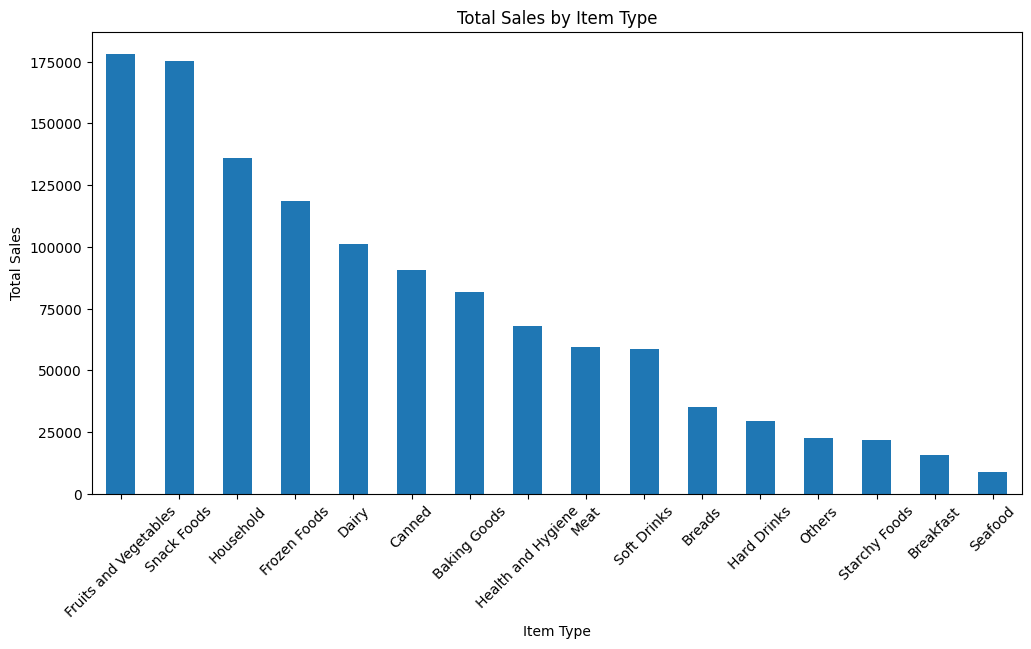

In [22]:
product_sales = (df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False))
product_sales.plot(kind="bar",figsize=(12,6))

plt.title("Total Sales by Item Type")
plt.xlabel("Item Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

**Business Insights**     
. Blinkit should ensure sufficient stock of Fruits & Vegetables to avoid inventory shortages.

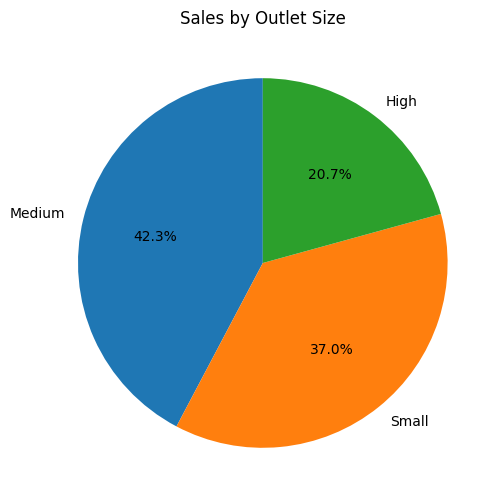

In [23]:
outlet_size_sales = (df.groupby("Outlet Size")["Sales"].sum().sort_values(ascending=False))

plt.figure(figsize=(6,6))
plt.pie(outlet_size_sales,labels=outlet_size_sales.index,autopct="%1.1f%%",startangle=90)
plt.title("Sales by Outlet Size")

plt.show()

**Business Insights**  
. Medium-sized outlets generate the higthest sales.  
. Medium-sized stores appear to balance inventory capacity and operating efficiency more effectively than small or large outlets.



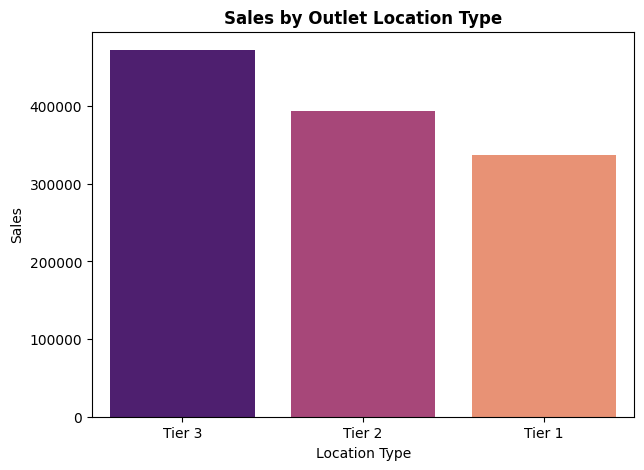

In [24]:
location_sales = df.groupby('Outlet Location Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=location_sales.index, y=location_sales.values, hue=location_sales.index, palette='magma', legend=False)
plt.title('Sales by Outlet Location Type', weight='bold')
plt.xlabel('Location Type')
plt.ylabel('Sales')
plt.show()

**Business Insights**   
. Tier 3 outlets contribute the highest revenue, indicating strong customer demand in these regions. Blinkit should prioritize expanding warehouse capacity and inventory availability in Tier 3 cities.



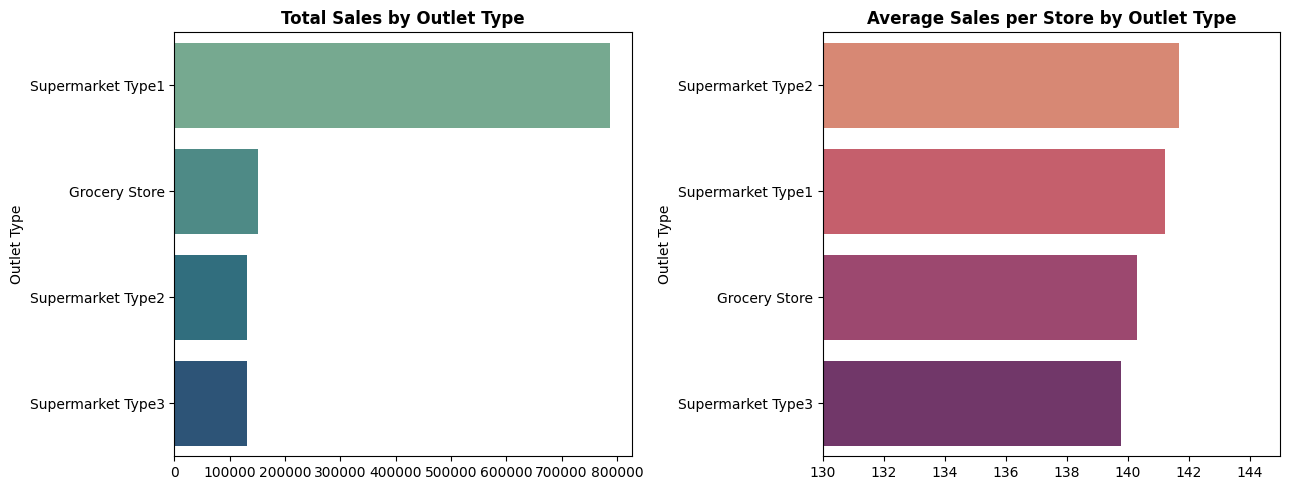

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

total = df.groupby('Outlet Type')['Sales'].sum().sort_values(ascending=False)
avgv = df.groupby('Outlet Type')['Sales'].mean().sort_values(ascending=False)

sns.barplot(x=total.values, y=total.index, hue=total.index, palette='crest', legend=False, ax=axes[0])
axes[0].set_title('Total Sales by Outlet Type', weight='bold')

sns.barplot(x=avgv.values, y=avgv.index, hue=avgv.index, palette='flare', legend=False, ax=axes[1])
axes[1].set_title('Average Sales per Store by Outlet Type', weight='bold')
axes[1].set_xlim(130,145)

plt.tight_layout()
plt.show()

**Business Insight**   

Supermarket Type1 contributes the largest share of Blinkit's total revenue, making it the best-performing outlet type overall.

**Business Insight**  

Although Supermarket Type1 generates the highest total revenue, Supermarket Type2 performs better on average at the individual store level. This suggests that each Supermarket Type2 store is more efficient in generating sales.

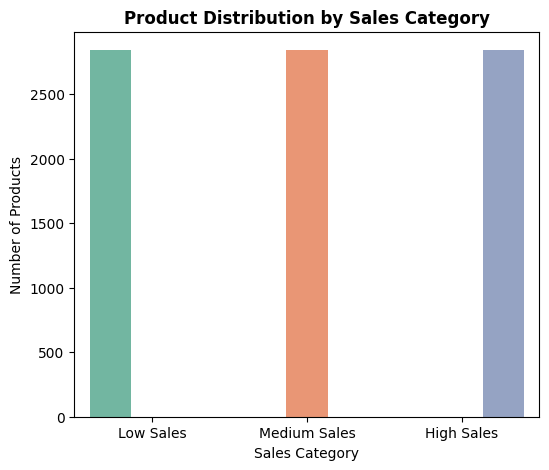

In [26]:
sales_category = df['Sales Category'].value_counts().sort_index()

plt.figure(figsize=(6,5))
sns.barplot(x=sales_category.index, y=sales_category.values, hue=sales_category.index, palette='Set2', legend=False)
plt.title('Product Distribution by Sales Category', weight='bold')
plt.xlabel('Sales Category')
plt.ylabel('Number of Products')
plt.show()



**Business Insight**  

. The products are almost equally distributed across Low, Medium, and High Sales categories. This shows a balanced sales distribution instead of most products falling into only one category.

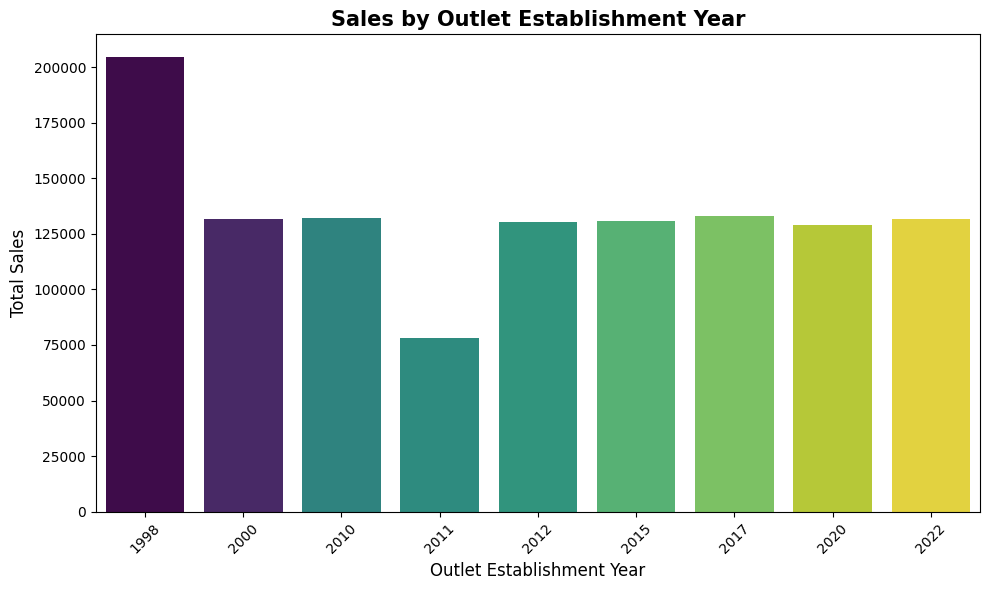

In [27]:
year_sales = df.groupby("Outlet Establishment Year")["Sales"].sum().sort_index()

plt.figure(figsize=(10,6))

sns.barplot(x=year_sales.index,y=year_sales.values,hue=year_sales.index,palette="viridis",legend=False)

plt.title("Sales by Outlet Establishment Year", fontsize=15, weight="bold")
plt.xlabel("Outlet Establishment Year", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Business Insight**  

. The analysis shows that sales vary across different outlet establishment years. Some outlet batches contribute higher sales than others, indicating differences in outlet performance. This suggests that factors such as outlet operations, location, and business strategy may influence sales performance.

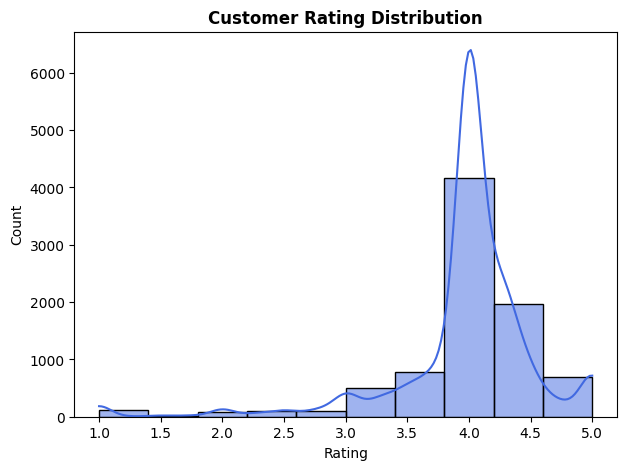

In [28]:
plt.figure(figsize=(7,5))
sns.histplot(df['Rating'], bins=10, kde=True, color='royalblue')
plt.title('Customer Rating Distribution', weight='bold')
plt.xlabel('Rating')
plt.show()

**Business Insights**     
. Most customers are satisfied with the products, indicating good overall product quality  
. Most customer ratings are around 4 out of 5.  
. Very few products have low ratings.

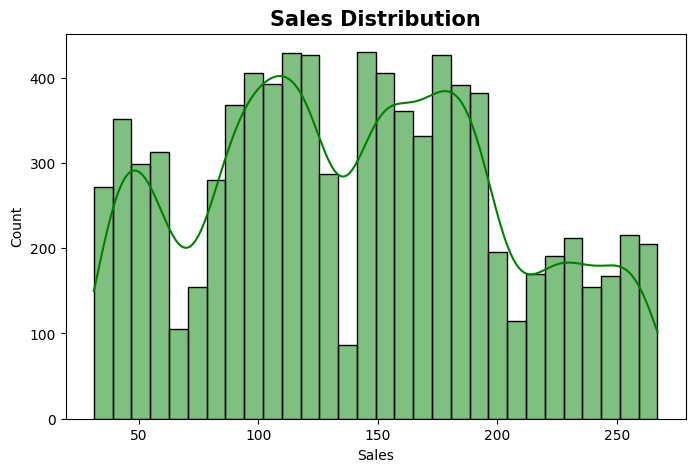

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["Sales"],bins=30,kde=True,color="green")

plt.title("Sales Distribution", fontsize=15, weight="bold")

plt.show()

**Business Insights**  
. Most products have sales between 100 and 200
. Only a few products have very low or very high sales.   
. Most products generate moderate sales showing a balanced sales pattern.



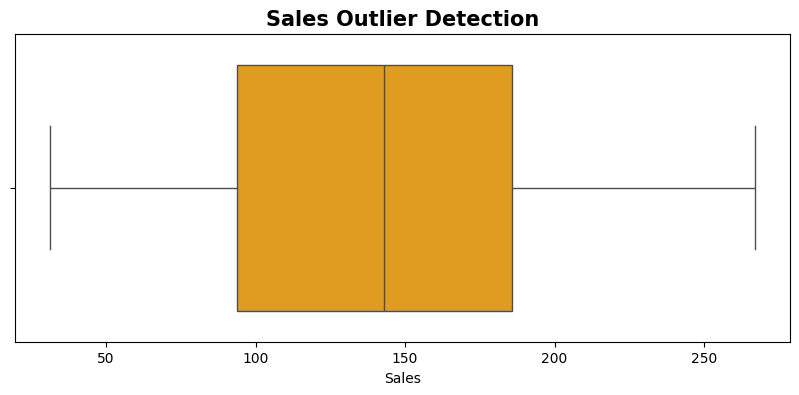

In [30]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["Sales"],color="orange")

plt.title("Sales Outlier Detection", fontsize=15, weight="bold")

plt.show()

**Business Insights**   
. Most sales values fall within a normal range.   
. No significant outliers are detected in the sales data.    
. The sales data is consistent and does not contain unusually high or low values.   



In [31]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['Sales'] < lower) | (df['Sales'] > upper)]
print(f"IQR bounds: [{lower:.1f}, {upper:.1f}]  |  Max Sales: {df['Sales'].max():.1f}  |  Outliers found: {len(outliers)}")

IQR bounds: [-43.9, 323.4]  |  Max Sales: 266.9  |  Outliers found: 0


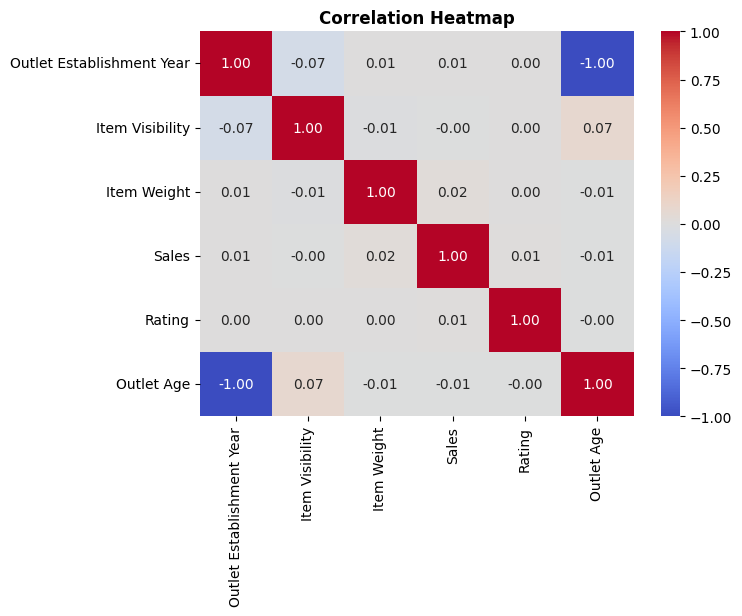

In [32]:
plt.figure(figsize=(7,5))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', weight='bold')
plt.show()

**business insights:**   

. Sales have very weak correlation with Item Weight, Item Visibility, Outlet Age, and Rating (all values close to 0).  
. Outlet Establishment Year and Outlet Age are perfectly negatively correlated (-1.00), which is expected since one is derived from the other.   
. Item Visibility has almost no impact on Sales.   
. Item Weight does not significantly influence Sales.    
. No strong linear relationships exist among most variables, suggesting Sales may depend on other factors such as product type, price, promotions, or outlet location.

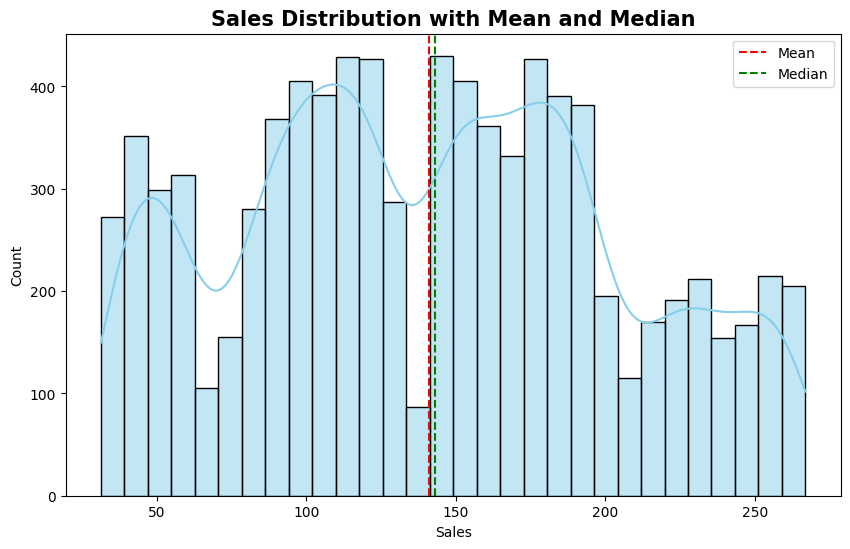

In [33]:
plt.figure(figsize=(10,6))

sns.histplot(df["Sales"], bins=30, kde=True, color="skyblue")

plt.axvline(df["Sales"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["Sales"].median(), color="green", linestyle="--", label="Median")

plt.title("Sales Distribution with Mean and Median", fontsize=15, weight="bold")
plt.xlabel("Sales")
plt.ylabel("Count")

plt.legend()

plt.show()

. The red (Mean) and green (Median) lines are almost overlapping.
. There is no large gap between them.  
. Mean and median are very close.

**Business Insight**  
.Sales data is stable, and there is no major difference between average sales and typical sales.



# Business Recommendation   

Based on the analysis, Blinkit should focus on expanding high-performing outlet types, maintaining sufficient stock of best-selling product categories, and increasing its presence in high-demand locations. The company should also improve the performance of low-selling products through targeted promotions and better product placement. By using data-driven decisions for inventory management, pricing, and store expansion, Blinkit can increase sales, improve customer satisfaction, and achieve sustainable business growth.